In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

wine = load_wine()
df = pd.DataFrame(data=wine.data,columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
# 컬렴명 확인
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

Text(0.5, 1.0, 'Label')

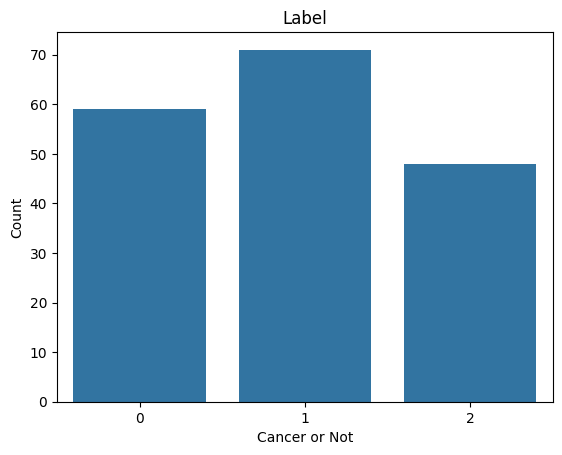

In [3]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="target")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [4]:
# 레이블 갯수 확인 (숫자)
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [5]:
# 결측치 확인
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [6]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

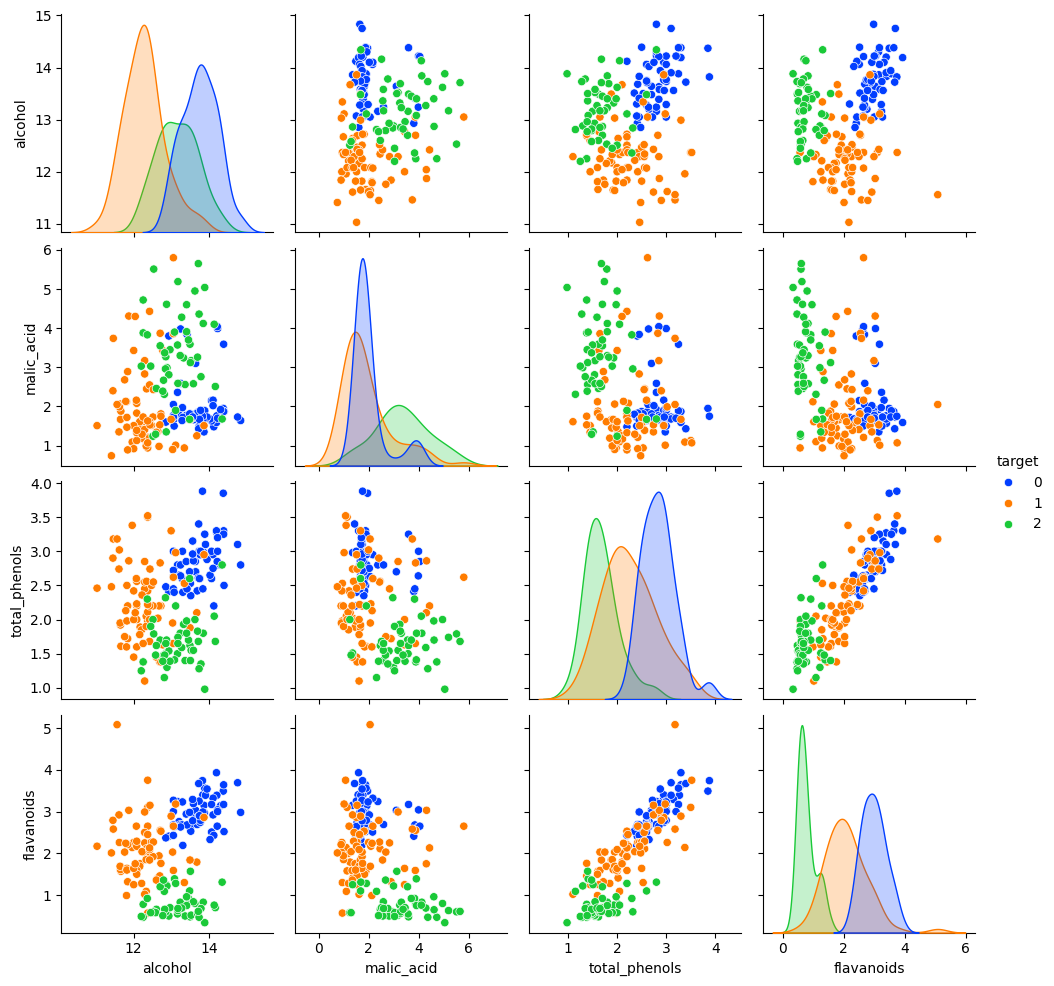

In [7]:
# pairplot로 와인의 주요 특징들 살펴보기
# 변수 이름은 df.columns에서 확인한 것들 중 4개를 골랐습니다.
sns.pairplot(df, 
             vars=['alcohol', 'malic_acid', 'total_phenols', 'flavanoids'], 
             hue='target', 
             palette='bright')
plt.show()

C:\Users\Jun\AppData\Local\Temp\ipykernel_17728\1049795492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="alcohol", data=df, palette="Set3")


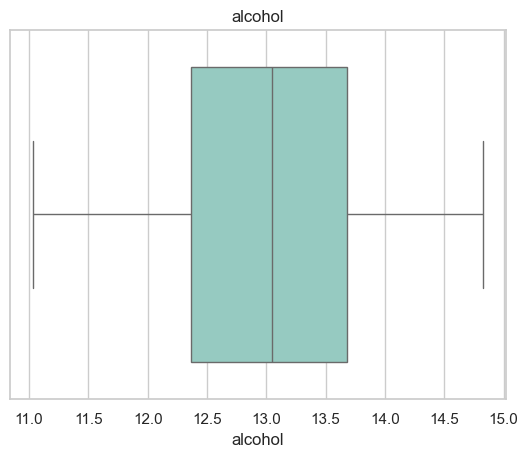

In [8]:
# 특정 칼럼의 범위 확인 및 outlier 확인

sns.set_theme(style="whitegrid")
sns.boxplot(x="alcohol", data=df, palette="Set3")
plt.title("alcohol")
plt.show()

C:\Users\Jun\AppData\Local\Temp\ipykernel_17728\2498552643.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax)


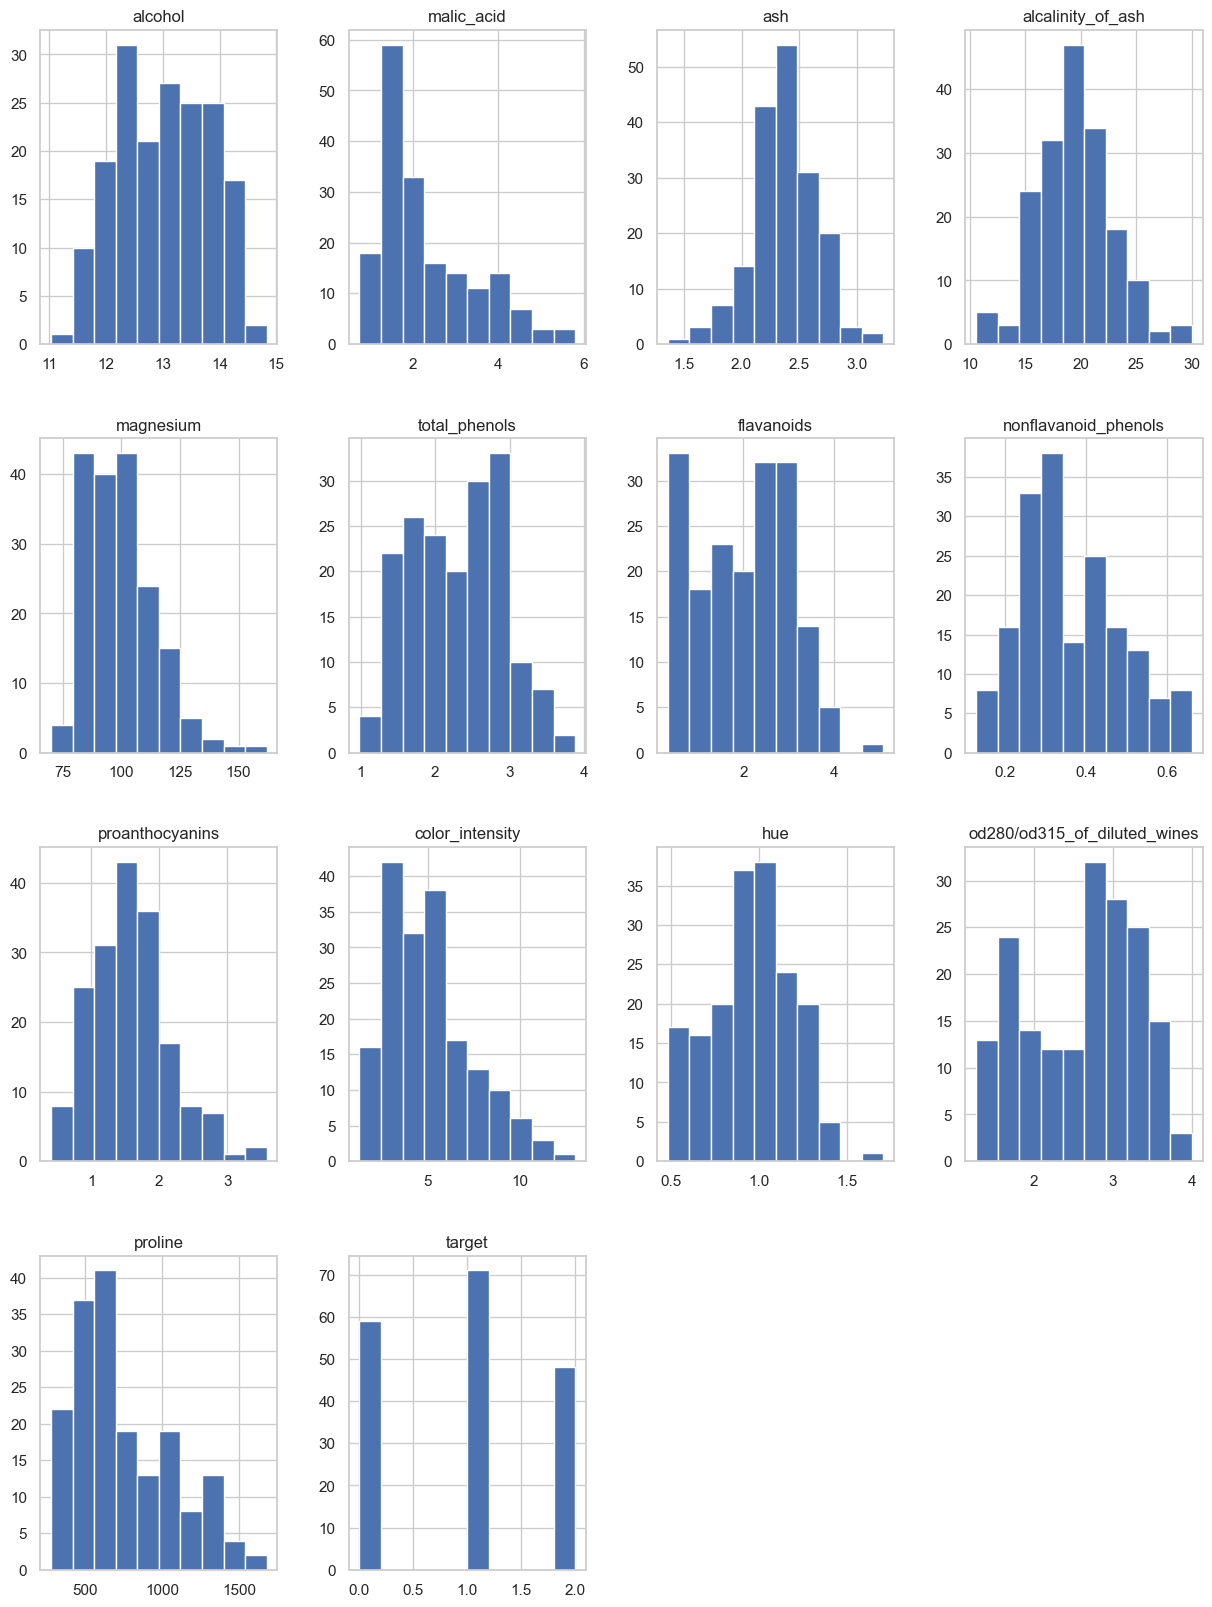

In [9]:
# 각 컬럼별 히스토 그램 확인

fig = plt.figure(figsize = (15,20))
ax = fig.gca()
df.hist(ax = ax)
plt.show()

In [10]:
X=df.drop('target',axis=1)
X.head()
y=df['target']
y.value_counts()
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [11]:
Y = pd.get_dummies(y).values
X = X.values

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0) 

In [13]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

model = Sequential()

# 1. 입력층 수정: 와인 데이터의 특징(컬럼) 개수는 13개이므로 input_shape=(13,)으로 변경
model.add(Dense(10, input_shape=(13,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(6, activation='relu'))

# 2. 출력층 수정: 와인 데이터의 정답(target)은 3종류(0, 1, 2)이므로 노드 수를 3으로 변경
model.add(Dense(3, activation='softmax'))

# 3. 컴파일 수정: 다중 분류(클래스가 3개 이상)이므로 'categorical_crossentropy' 사용
# (주의: 최신 케라스 버전에서는 'lr' 대신 'learning_rate'를 사용합니다)
model.compile(optimizer=Adam(learning_rate=0.04), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 1. 모델 학습 (y 값에 인코딩된 데이터를 넣습니다)
model_history = model.fit(x=X_train, 
                          y=y_train, 
                          epochs=30, 
                          batch_size=32, 
                          validation_data=(X_test, y_test))

# 2. 테스트 데이터로 예측 진행
y_pred = model.predict(X_test)

# 3. 가장 높은 확률을 가진 인덱스를 추출하여 클래스(0, 1, 2)로 변환
y_pred_class = np.argmax(y_pred, axis=1)
y_test_class = np.argmax(y_test, axis=1) 

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.3521 - loss: 4.9768 - val_accuracy: 0.4444 - val_loss: 1.0660
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3873 - loss: 1.0943 - val_accuracy: 0.4444 - val_loss: 1.0560
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3873 - loss: 1.0948 - val_accuracy: 0.4444 - val_loss: 1.0535
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3873 - loss: 1.0946 - val_accuracy: 0.4444 - val_loss: 1.0554
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3873 - loss: 1.0944 - val_accuracy: 0.4444 - val_loss: 1.0627
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3873 - loss: 1.0932 - val_accuracy: 0.4444 - val_loss: 1.0665
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3873 - loss: 1.0930 - val_accuracy: 0.4444 - val_loss: 1.0679
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3873 - loss: 1.0918 - val_accuracy: 0.4444 - val_loss: 1.0698


In [15]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.62        16
           2       0.00      0.00      0.00         6

    accuracy                           0.44        36
   macro avg       0.15      0.33      0.21        36
weighted avg       0.20      0.44      0.27        36

[[ 0 14  0]
 [ 0 16  0]
 [ 0  6  0]]


C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classifica

In [16]:
clf_df = df # move df to classfication df
y = clf_df['target']             # target
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [17]:
X = clf_df.drop('target', axis=1) # fitting data
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lg_model = LogisticRegression(random_state=0)
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeClassifier(random_state=0)
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestClassifier(random_state=0)
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsClassifier(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.metrics import accuracy_score # 정확도
from sklearn.metrics import confusion_matrix #혼동행렬 ==> k fold

print('---- logistic regression ----')
print(accuracy_score(y_test, lg_y))
print(confusion_matrix(y_test, lg_y))

print('---- decision tree classifier ----')
print(accuracy_score(y_test, De_y))
print(confusion_matrix(y_test, De_y))

print('---- random forest classifier ----')
print(accuracy_score(y_test, Rd_y))
print(confusion_matrix(y_test, Rd_y))

print('---- KNeighborsClassifier ----')
print(accuracy_score(y_test, KN_y))
print(confusion_matrix(y_test, KN_y))

---- logistic regression ----
0.9166666666666666
[[13  1  0]
 [ 1 14  1]
 [ 0  0  6]]
---- decision tree classifier ----
0.9166666666666666
[[13  1  0]
 [ 1 14  1]
 [ 0  0  6]]
---- random forest classifier ----
0.9166666666666666
[[13  1  0]
 [ 1 14  1]
 [ 0  0  6]]
---- KNeighborsClassifier ----
0.8055555555555556
[[13  0  1]
 [ 0 14  2]
 [ 2  2  2]]


In [21]:
reg_df = df
y = reg_df['alcohol']             # target
y.head() 

0    14.23
1    13.20
2    13.16
3    14.37
4    13.24
Name: alcohol, dtype: float64

In [22]:
X = reg_df.drop('alcohol', axis=1) # fitting data
X = X.drop('target', axis=1) # fitting data
X.head()

,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lg_model = LinearRegression()
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeRegressor()
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestRegressor()
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)



In [25]:
from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,lg_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,De_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,Rd_y))

---- LinearRegression ----
0.39482077365100554
---- DecisionTreeRegressor ----
0.39482077365100554
---- RandomForestRegressor ----
0.39482077365100554
